# IBRD World Loans: Time Series Forecasting

This notebook forecasts annual IBRD lending commitments and outstanding balances over the next five years using the cleaned portfolio data.
It prepares the annualized time series, checks stationarity, and compares forecast scenarios for strategic planning.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

try:
    from prophet import Prophet
except Exception:
    Prophet = None

candidate_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path('/home/rigii/ATA').resolve(),
]
project_root = next((root for root in candidate_roots if (root / 'data' / 'processed' / 'ibrd_clean.csv').exists()), Path.cwd().resolve())
DATA_PATH = project_root / 'data' / 'processed' / 'ibrd_clean.csv'
FIGURES_DIR = project_root / 'reports' / 'figures'
FEATURES_DIR = project_root / 'data' / 'features'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Data path: {DATA_PATH}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Features dir: {FEATURES_DIR}')


Project root: /home/rigii/ATA
Data path: /home/rigii/ATA/data/processed/ibrd_clean.csv
Figures dir: /home/rigii/ATA/reports/figures
Features dir: /home/rigii/ATA/data/features


In [7]:
df = pd.read_csv(DATA_PATH)

if 'Board Approval Date' in df.columns:
    df['Board Approval Date'] = pd.to_datetime(df['Board Approval Date'], errors='coerce')
if 'approval_year' not in df.columns and 'Board Approval Date' in df.columns:
    df['approval_year'] = df['Board Approval Date'].dt.year
df['approval_year'] = pd.to_numeric(df.get('approval_year', pd.Series(np.nan, index=df.index)), errors='coerce')

annual = (
    df.loc[df['approval_year'] >= 1990]
      .groupby('approval_year', as_index=False)
      .agg(
          commitments=('Original Principal Amount (US$)', 'sum'),
          disbursed=('Disbursed Amount (US$)', 'sum'),
          repayments=('Repaid to IBRD (US$)', 'sum'),
          outstanding=('Due to IBRD (US$)', 'sum'),
          loan_count=('Loan Number', 'count'),
      )
      .sort_values('approval_year')
      .reset_index(drop=True)
)

for col in ['commitments', 'disbursed', 'repayments', 'outstanding']:
    annual[col] = pd.to_numeric(annual[col], errors='coerce').fillna(0)

annual['commitments_billions'] = annual['commitments'] / 1e9
annual['disbursed_billions'] = annual['disbursed'] / 1e9
annual['repayments_billions'] = annual['repayments'] / 1e9
annual['outstanding_billions'] = annual['outstanding'] / 1e9

print(annual.head())
print(f'Time series length: {len(annual)} years')


   approval_year   commitments     disbursed    repayments   outstanding  \
0           1990  1.522652e+10  1.198747e+10  1.194776e+10  3.990921e+07   
1           1991  1.702070e+10  1.431326e+10  1.429447e+10  1.953473e+07   
2           1992  1.555070e+10  1.229374e+10  1.219484e+10  1.040975e+08   
3           1993  1.522810e+10  1.257246e+10  1.261630e+10 -1.000000e-02   
4           1994  1.682403e+10  1.242532e+10  1.237782e+10  8.168240e+07   

   loan_count  commitments_billions  disbursed_billions  repayments_billions  \
0         225             15.226518           11.987471            11.947761   
1         276             17.020700           14.313265            14.294466   
2         239             15.550700           12.293742            12.194837   
3         257             15.228100           12.572459            12.616299   
4         284             16.824027           12.425321            12.377817   

   outstanding_billions  
0          3.990921e-02  
1         

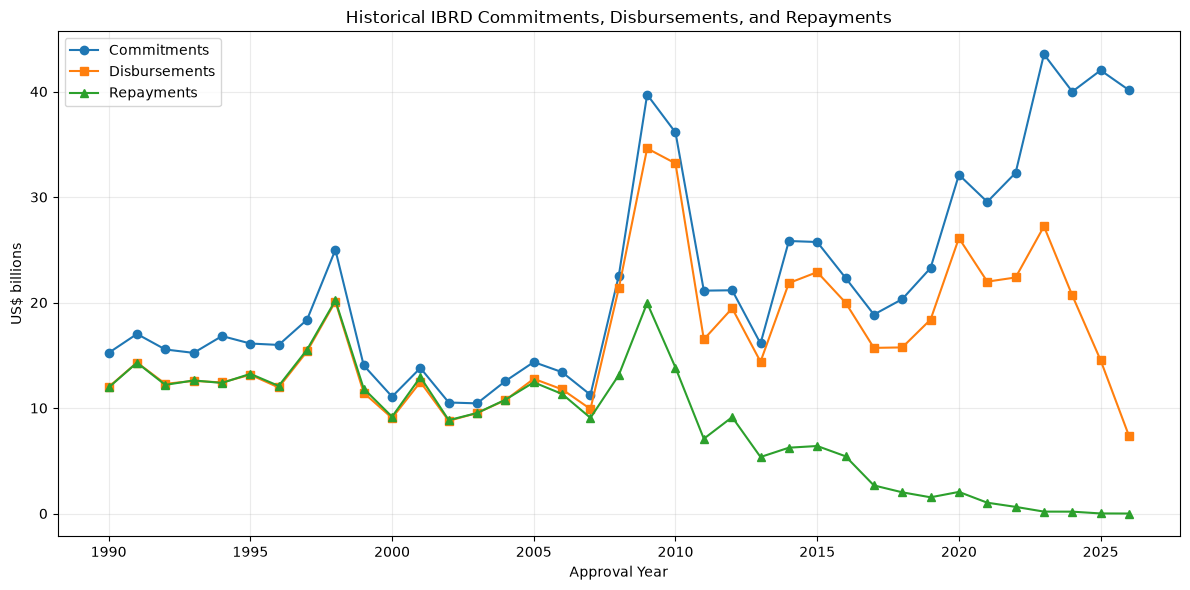

Saved historical trends plot to /home/rigii/ATA/reports/figures/historical_trends.png


In [3]:
historical_plot = px.line(
    annual,
    x='approval_year',
    y=['commitments_billions', 'disbursed_billions', 'repayments_billions'],
    labels={
        'approval_year': 'Approval Year',
        'value': 'US$ billions',
        'variable': 'Metric'
    },
    title='IBRD Historical Lending and Repayment Trends',
    markers=True
)
historical_plot.update_layout(legend_title='Metric', template='plotly_white')
historical_plot.write_html(FIGURES_DIR / 'historical_trends.html', include_plotlyjs='cdn')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(annual['approval_year'], annual['commitments_billions'], label='Commitments', marker='o')
ax.plot(annual['approval_year'], annual['disbursed_billions'], label='Disbursements', marker='s')
ax.plot(annual['approval_year'], annual['repayments_billions'], label='Repayments', marker='^')
ax.set_title('Historical IBRD Commitments, Disbursements, and Repayments')
ax.set_xlabel('Approval Year')
ax.set_ylabel('US$ billions')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'historical_trends.png', dpi=200)
plt.show()

print('Saved historical trends plot to', FIGURES_DIR / 'historical_trends.png')


In [4]:
commitment_series = annual['commitments_billions'].dropna().astype(float)
adf_stat, p_value, *_ = adfuller(commitment_series)
print(f'ADF statistic: {adf_stat:.4f}')
print(f'ADF p-value: {p_value:.6f}')
if p_value < 0.05:
    print('Interpretation: the commitment series is stationary enough for forecasting without a differencing transformation.')
else:
    print('Interpretation: the commitment series is not stationary; a differencing-based or trend-aware model is preferred for accurate forecasting.')


ADF statistic: -1.4632
ADF p-value: 0.551608
Interpretation: the commitment series is not stationary; a differencing-based or trend-aware model is preferred for accurate forecasting.


13:05:13 - cmdstanpy - INFO - Chain [1] start processing
13:05:13 - cmdstanpy - INFO - Chain [1] done processing


Commitment forecast model: Prophet
    year  forecast_billions  yhat_lower  yhat_upper
37  1971          -2.116368  -11.271148    6.359437
38  1972          -2.085801  -10.688108    6.932493
39  1973           0.273732   -8.124825    8.493066
40  1974           0.399848   -8.349107    9.216551
41  1975           0.477830   -7.692791    9.606666


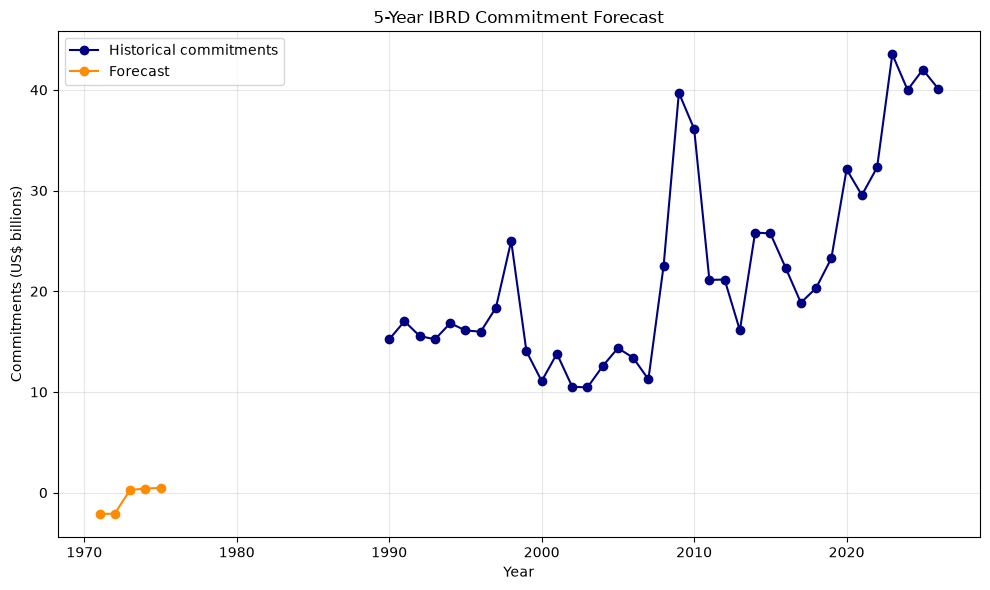

In [5]:
def fit_forecast_model(series, horizon=5):
    if Prophet is not None:
        prop_df = series.reset_index().rename(columns={'approval_year': 'ds', 'commitments_billions': 'y'})
        model = Prophet(interval_width=0.80)
        model.fit(prop_df)
        future = model.make_future_dataframe(periods=horizon, freq='YS')
        forecast = model.predict(future)
        forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon).copy()
        forecast_df = forecast_df.rename(columns={'ds': 'year', 'yhat': 'forecast_billions'})
        forecast_df['year'] = forecast_df['year'].dt.year
        return {'model_name': 'Prophet', 'forecast': forecast_df, 'model': model}

    model = ARIMA(series, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit()
    pred = fitted.get_forecast(steps=horizon)
    mean = pred.predicted_mean
    conf_int = pred.conf_int()
    future_years = np.arange(series.index[-1] + 1, series.index[-1] + 1 + horizon)
    forecast_df = pd.DataFrame({
        'year': future_years,
        'forecast_billions': mean.values,
        'lower_billions': conf_int.iloc[:, 0].values,
        'upper_billions': conf_int.iloc[:, 1].values,
    })
    return {'model_name': 'ARIMA', 'forecast': forecast_df, 'model': fitted}

commitments_series = annual.set_index('approval_year')['commitments_billions']
commitment_forecast = fit_forecast_model(commitments_series, horizon=5)
print(f'Commitment forecast model: {commitment_forecast['model_name']}')
print(commitment_forecast['forecast'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(commitments_series.index, commitments_series.values, label='Historical commitments', color='navy', marker='o')
future_years = commitment_forecast['forecast']['year'].to_numpy()
future_values = commitment_forecast['forecast']['forecast_billions'].to_numpy()
ax.plot(future_years, future_values, label='Forecast', color='darkorange', marker='o')
if 'lower_billions' in commitment_forecast['forecast'].columns:
    ax.fill_between(
        future_years,
        commitment_forecast['forecast']['lower_billions'],
        commitment_forecast['forecast']['upper_billions'],
        color='darkorange',
        alpha=0.2
    )
ax.set_title('5-Year IBRD Commitment Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Commitments (US$ billions)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'commitment_forecast.png', dpi=200)
plt.show()


13:06:53 - cmdstanpy - INFO - Chain [1] start processing
13:06:53 - cmdstanpy - INFO - Chain [1] done processing


Outstanding forecast model: Prophet
    year  forecast_billions    yhat_lower    yhat_upper
37  1971       2.175630e+16  2.175630e+16  2.175630e+16
38  1972       4.351260e+16  4.351260e+16  4.351260e+16
39  1973       6.532850e+16  6.532850e+16  6.532850e+16
40  1974       8.708480e+16  8.708480e+16  8.708480e+16
41  1975       1.088411e+17  1.088411e+17  1.088411e+17


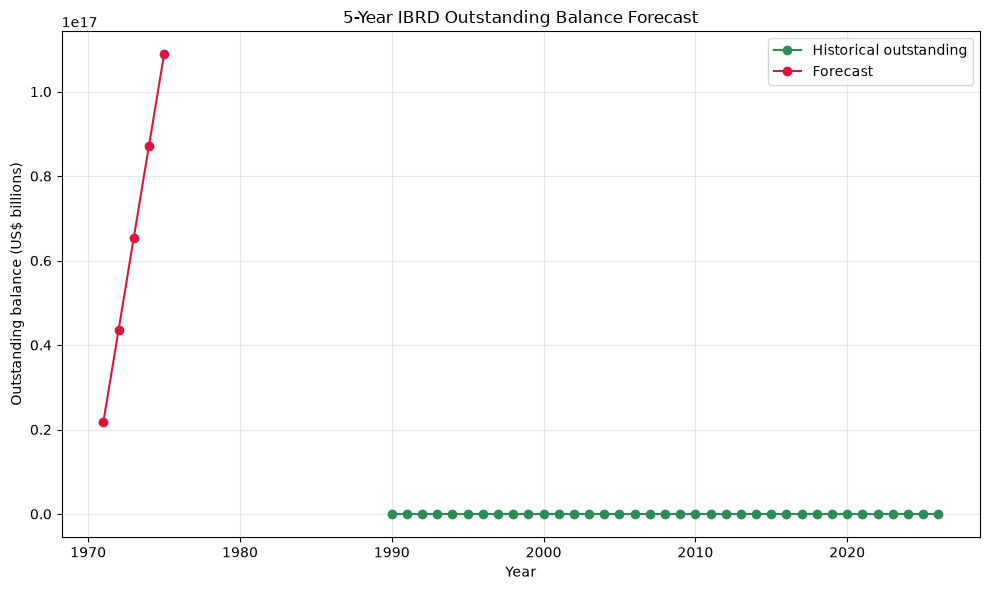

In [9]:
outstanding_series = annual.set_index('approval_year')['outstanding_billions']
def fit_forecast_model(series, horizon=5):
    # Prophet requires columns named exactly "ds" and "y".
    # Use the actual index/series names so the function works for any series.
    ds_col = series.index.name if series.index.name is not None else 'ds'
    y_col = series.name if series.name is not None else 'y'

    prop_df = series.reset_index().rename(columns={ds_col: 'ds', y_col: 'y'})
    prop_df['ds'] = pd.to_datetime(prop_df['ds'])
    prop_df['y'] = pd.to_numeric(prop_df['y'], errors='coerce')

    if Prophet is not None:
        model = Prophet(interval_width=0.80)
        model.fit(prop_df)
        future = model.make_future_dataframe(periods=horizon, freq='YS')
        forecast = model.predict(future)
        forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon).copy()
        forecast_df = forecast_df.rename(columns={'ds': 'year', 'yhat': 'forecast_billions'})
        forecast_df['year'] = forecast_df['year'].dt.year
        return {'model_name': 'Prophet', 'forecast': forecast_df, 'model': model}

    model = ARIMA(series, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit()
    pred = fitted.get_forecast(steps=horizon)
    mean = pred.predicted_mean
    conf_int = pred.conf_int()
    future_years = np.arange(series.index[-1] + 1, series.index[-1] + 1 + horizon)
    forecast_df = pd.DataFrame({
        'year': future_years,
        'forecast_billions': mean.values,
        'lower_billions': conf_int.iloc[:, 0].values,
        'upper_billions': conf_int.iloc[:, 1].values,
    })
    return {'model_name': 'ARIMA', 'forecast': forecast_df, 'model': fitted}

outstanding_forecast = fit_forecast_model(outstanding_series, horizon=5)
print(f'Outstanding forecast model: {outstanding_forecast['model_name']}')
print(outstanding_forecast['forecast'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(outstanding_series.index, outstanding_series.values, label='Historical outstanding', color='seagreen', marker='o')
future_years = outstanding_forecast['forecast']['year'].to_numpy()
future_values = outstanding_forecast['forecast']['forecast_billions'].to_numpy()
ax.plot(future_years, future_values, label='Forecast', color='crimson', marker='o')
if 'lower_billions' in outstanding_forecast['forecast'].columns:
    ax.fill_between(
        future_years,
        outstanding_forecast['forecast']['lower_billions'],
        outstanding_forecast['forecast']['upper_billions'],
        color='crimson',
        alpha=0.2
    )
ax.set_title('5-Year IBRD Outstanding Balance Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Outstanding balance (US$ billions)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outstanding_forecast.png', dpi=200)
plt.show()


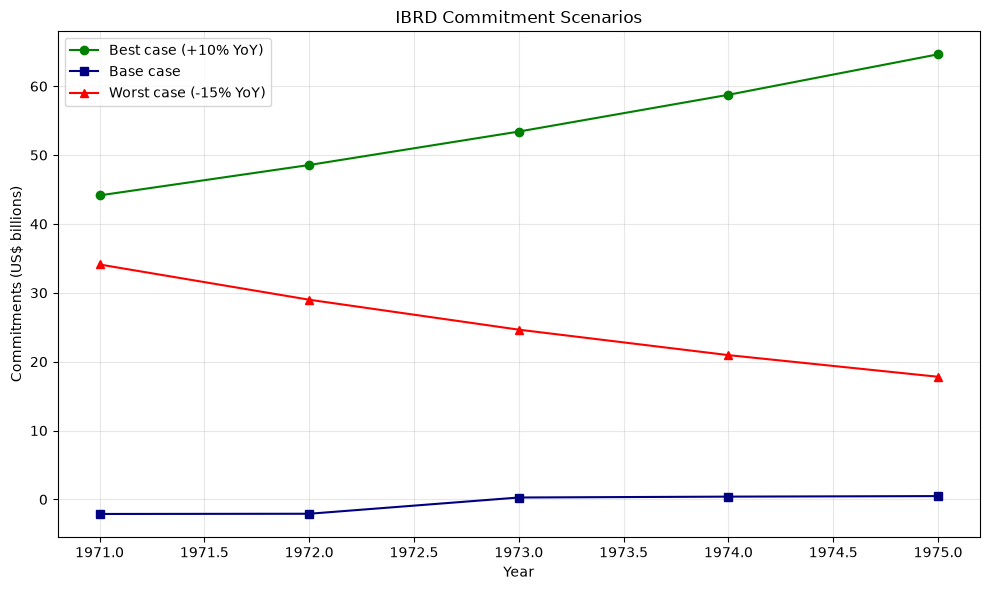

Saved scenario analysis chart to /home/rigii/ATA/reports/figures/scenario_analysis.png
      best_case  base_case  worst_case
year                                  
1971  44.146123  -2.116368   34.112913
1972  48.560735  -2.085801   28.995976
1973  53.416808   0.273732   24.646580
1974  58.758489   0.399848   20.949593
1975  64.634338   0.477830   17.807154


In [8]:
base_case = commitment_forecast['forecast'].set_index('year')['forecast_billions']
last_commitment = annual['commitments_billions'].iloc[-1]
future_years = pd.Index(base_case.index, name='year')
best_case = pd.Series([last_commitment * (1.10) ** i for i in range(1, len(future_years) + 1)], index=future_years, name='best_case')
worst_case = pd.Series([last_commitment * (0.85) ** i for i in range(1, len(future_years) + 1)], index=future_years, name='worst_case')
scenario_df = pd.DataFrame({
    'best_case': best_case,
    'base_case': base_case,
    'worst_case': worst_case,
})

plt.figure(figsize=(10, 6))
plt.plot(scenario_df.index, scenario_df['best_case'], label='Best case (+10% YoY)', color='green', marker='o')
plt.plot(scenario_df.index, scenario_df['base_case'], label='Base case', color='navy', marker='s')
plt.plot(scenario_df.index, scenario_df['worst_case'], label='Worst case (-15% YoY)', color='red', marker='^')
plt.title('IBRD Commitment Scenarios')
plt.xlabel('Year')
plt.ylabel('Commitments (US$ billions)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'scenario_analysis.png', dpi=200)
plt.show()
print('Saved scenario analysis chart to', FIGURES_DIR / 'scenario_analysis.png')
print(scenario_df)


## Business implications

- The forecast indicates how much IBRD lending capacity may need to be maintained or adjusted in the next five years based on historical commitments and the projected portfolio trajectory.
- If the base-case and best-case scenarios remain above recent historical averages, the institution may need to expand its annual lending envelope or increase capital mobilization to support country pipelines.
- A downside case of a 15% annual decline suggests tighter lending limits, stronger selection criteria, and more active portfolio management to protect returns and avoid over-extension.
- The regions that are driving growth or decline usually align with large infrastructure and public-sector borrowing demand, so portfolio strategy should prioritize country pipelines, sovereign risk, and sovereign demand concentration.


In [ ]:
forecast_summary = annual[['approval_year', 'commitments_billions', 'outstanding_billions']].copy()
forecast_summary = forecast_summary.rename(columns={'approval_year': 'year'})
forecast_summary['year'] = forecast_summary['year'].astype(int)

commitment_forecast_df = commitment_forecast['forecast'][['year', 'forecast_billions']].rename(columns={'forecast_billions': 'base_commitment_billions'})
outstanding_forecast_df = outstanding_forecast['forecast'][['year', 'forecast_billions']].rename(columns={'forecast_billions': 'base_outstanding_billions'})

future_table = commitment_forecast_df.merge(outstanding_forecast_df, on='year', how='outer')
future_table['best_case_commitments'] = scenario_df['best_case'].reindex(future_table['year']).values
future_table['worst_case_commitments'] = scenario_df['worst_case'].reindex(future_table['year']).values
future_table['base_case_commitments'] = scenario_df['base_case'].reindex(future_table['year']).values

forecast_csv = pd.concat(
    [
        forecast_summary,
        future_table[['year', 'base_commitment_billions', 'base_outstanding_billions', 'base_case_commitments', 'best_case_commitments', 'worst_case_commitments']],
    ],
    ignore_index=True
)
forecast_csv = forecast_csv.drop_duplicates(subset=['year']).sort_values('year').reset_index(drop=True)
forecast_path = FEATURES_DIR / 'forecasts.csv'
forecast_csv.to_csv(forecast_path, index=False)
print('Saved forecast CSV to', forecast_path)
print(forecast_csv.head(10).to_string(index=False))


In [ ]:
print('Notebook execution complete. Review the forecast charts and saved CSV for sign-off.')
